# The Cost of Being Black While Giving Birth

## Exploring the Data

In [1]:
# Imports and Setup

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

sb.set(style="whitegrid")


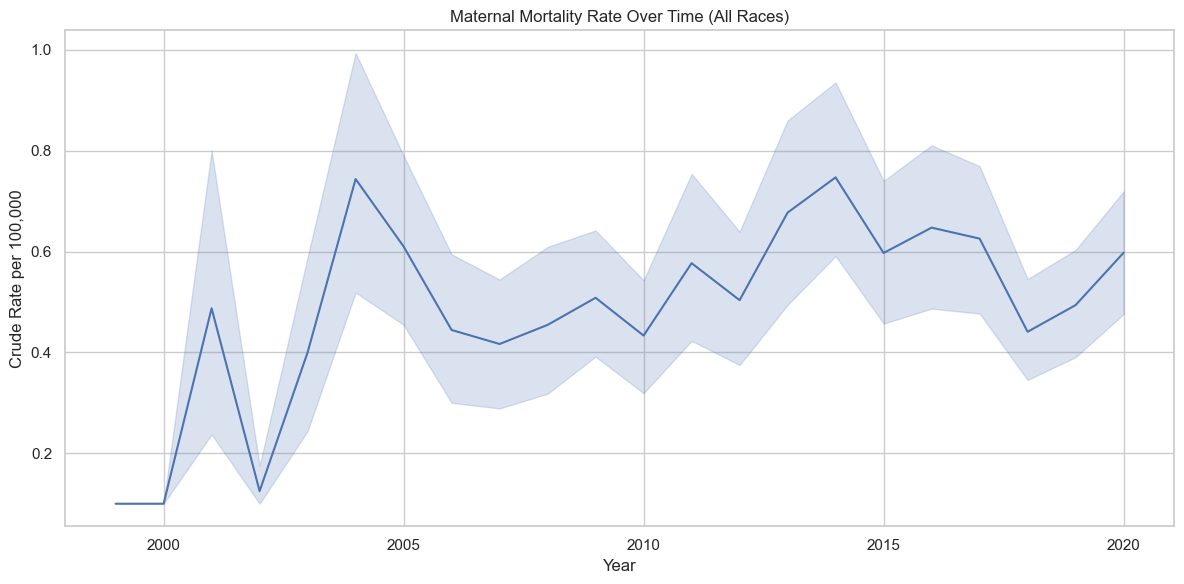

In [ ]:
# Trendline: Maternal Mortality Rate in the United States (All Races, 1999-2022)

df = pd.read_csv(r'\data\cleaned_maternal_mortality.csv')

plt.figure(figsize=(12, 6))
sb.lineplot(data=df, x="year", y="crude_rate", estimator="mean")
plt.title("Maternal Mortality Rate Over Time (All Races)")
plt.xlabel("Year")
plt.ylabel("Crude Rate per 100,000")
plt.tight_layout()
plt.show()

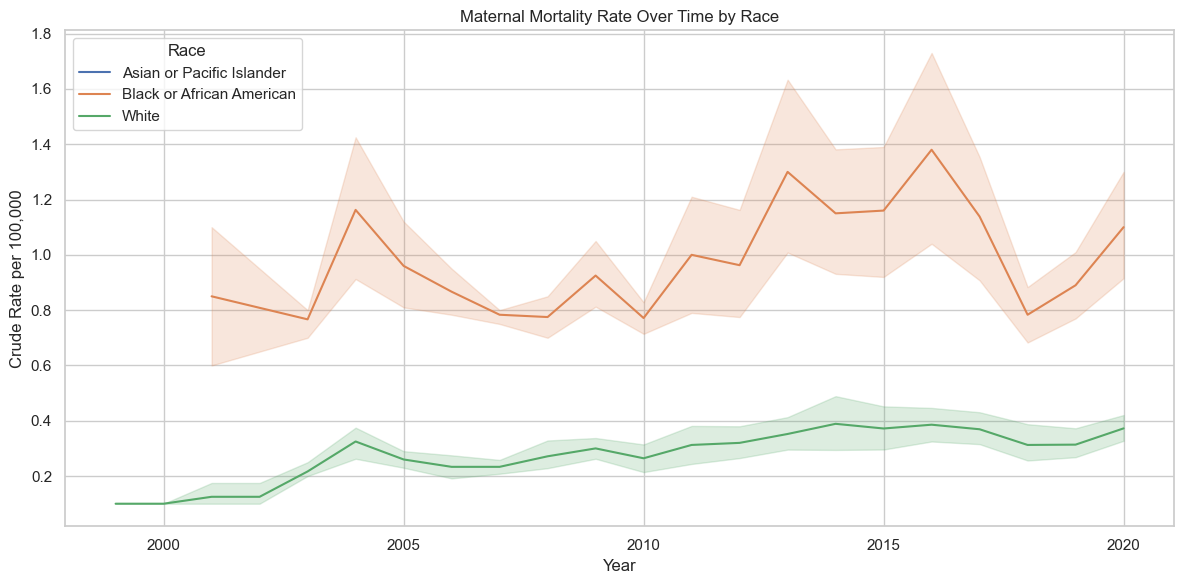

In [4]:
# Trendline by Race

plt.figure(figsize=(12, 6))
sb.lineplot(data=df, x="year", y="crude_rate", hue="race")
plt.title("Maternal Mortality Rate Over Time by Race")
plt.xlabel("Year")
plt.ylabel("Crude Rate per 100,000")
plt.legend(title="Race")
plt.tight_layout()
plt.show()

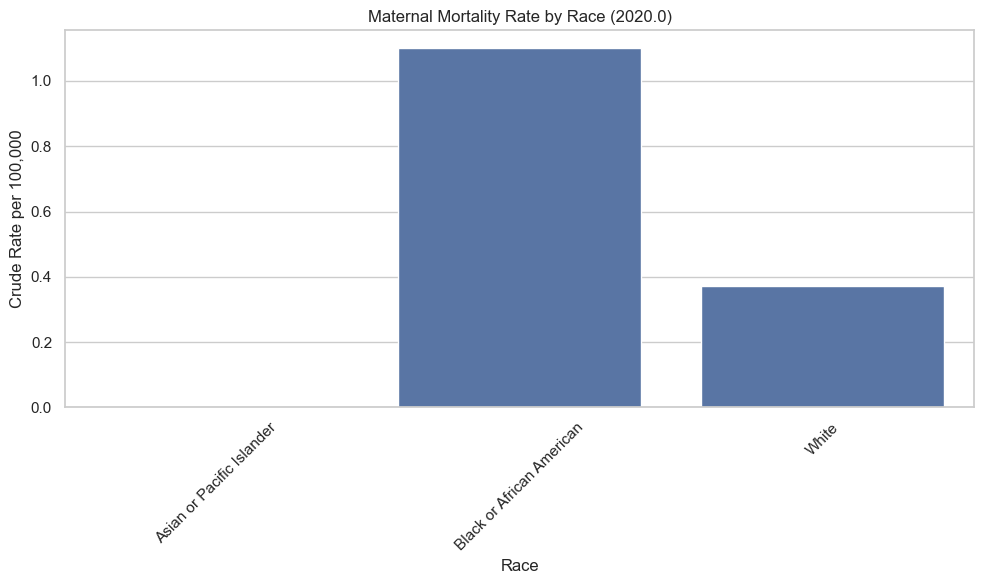

In [5]:
# Bar Chart: Maternal Mortality Rate by Race (2020)

latest_year = df['year'].max()
df_latest = df[df['year'] == latest_year]

plt.figure(figsize=(10, 6))
sb.barplot(data=df_latest, x="race", y="crude_rate", errorbar=None)
plt.title(f"Maternal Mortality Rate by Race ({latest_year})")
plt.xlabel("Race")
plt.ylabel("Crude Rate per 100,000")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Monchelle\AppData\Local\Temp\ipykernel_37996\929217177.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=df_state.sort_values("crude_rate", ascending=False),


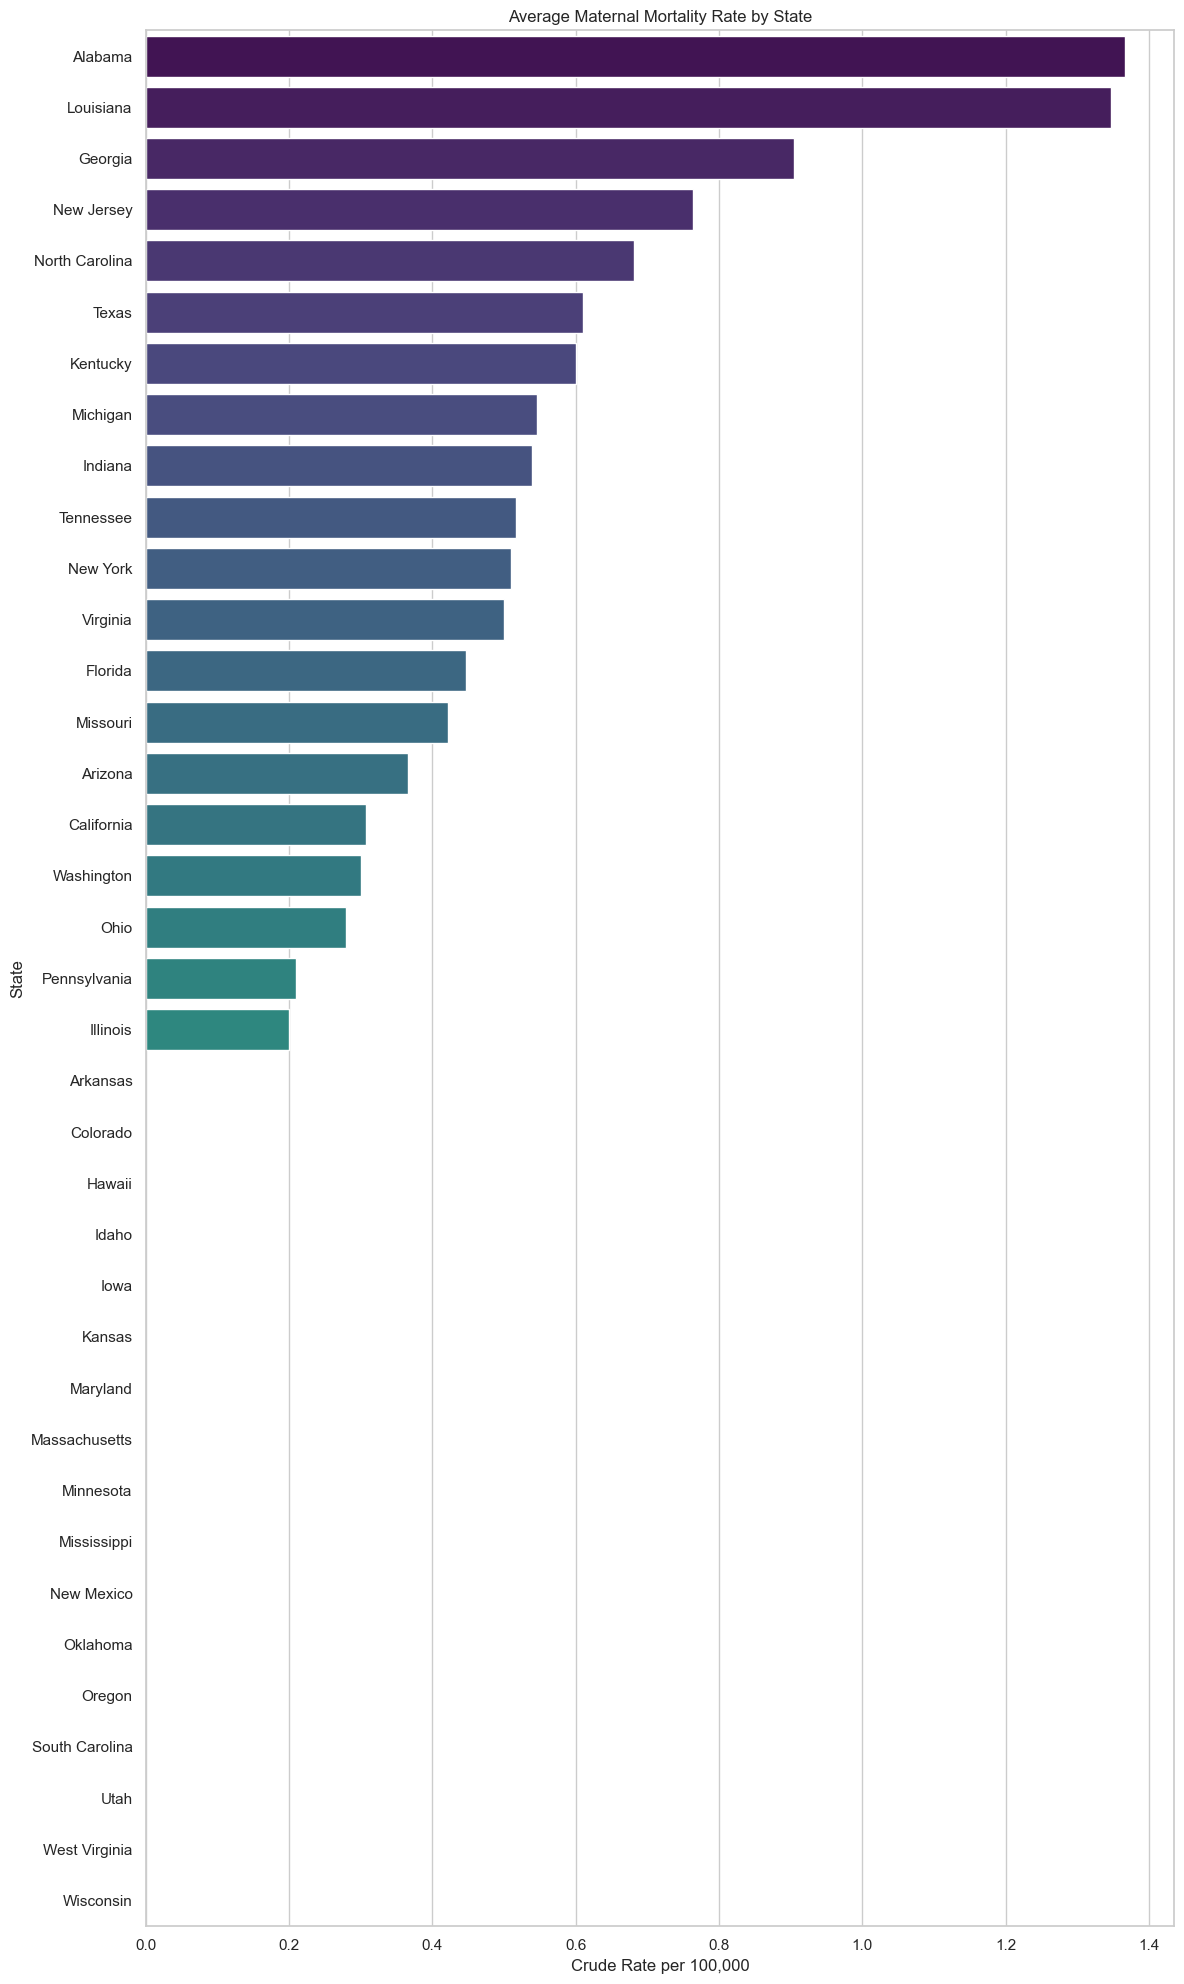

In [7]:
# State-Level Heatmap: Average Maternal Mortality Rate by State

df_state = df.groupby("state")["crude_rate"].mean().reset_index()

plt.figure(figsize=(12, 20))
sb.barplot(data=df_state.sort_values("crude_rate", ascending=False),
            y="state", x="crude_rate", palette="viridis")
plt.title("Average Maternal Mortality Rate by State")
plt.xlabel("Crude Rate per 100,000")
plt.ylabel("State")
plt.tight_layout()
plt.show()

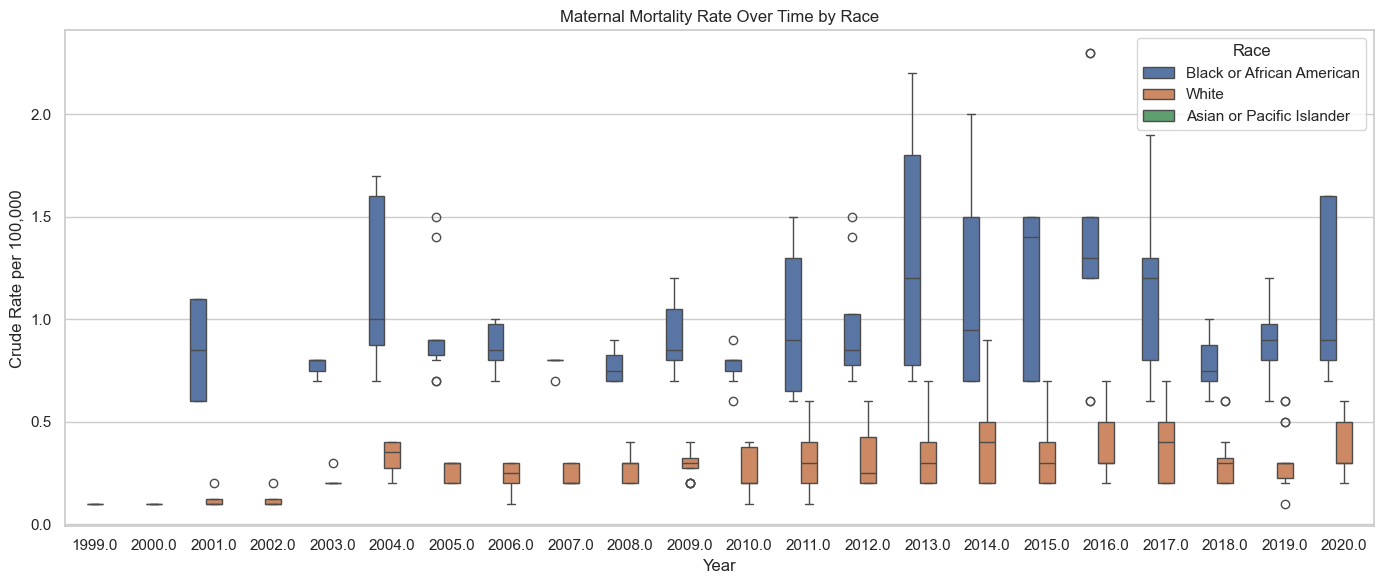

In [11]:
# Distribution Plot: Crude Rate Distribution

plt.figure(figsize=(14, 6))
sb.boxplot(data=df, x="year", y="crude_rate", hue="race")
plt.title("Maternal Mortality Rate Over Time by Race")
plt.xlabel("Year")
plt.ylabel("Crude Rate per 100,000")
plt.legend(title="Race")
plt.tight_layout()
plt.show()

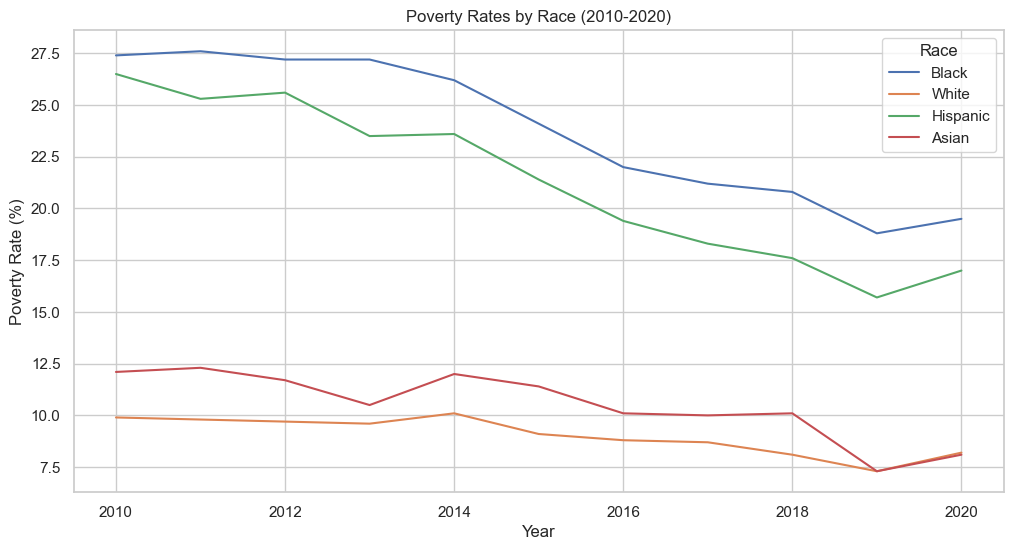

In [ ]:
# Poverty Rates Over Time by Race

df = pd.read_csv(r'\data\poverty-rates.csv')

plt.figure(figsize=(12, 6))
sb.lineplot(data=df, x="Year", y='Black', label='Black')
sb.lineplot(data=df, x="Year", y='White (Non-Hispanic)', label='White')
sb.lineplot(data=df, x="Year", y='Hispanic', label='Hispanic')
sb.lineplot(data=df, x="Year", y='Asian', label='Asian')

plt.title("Poverty Rates by Race (2010-2020)")
plt.ylabel("Poverty Rate (%)")
plt.xlabel("Year")
plt.legend(title="Race")
plt.show()

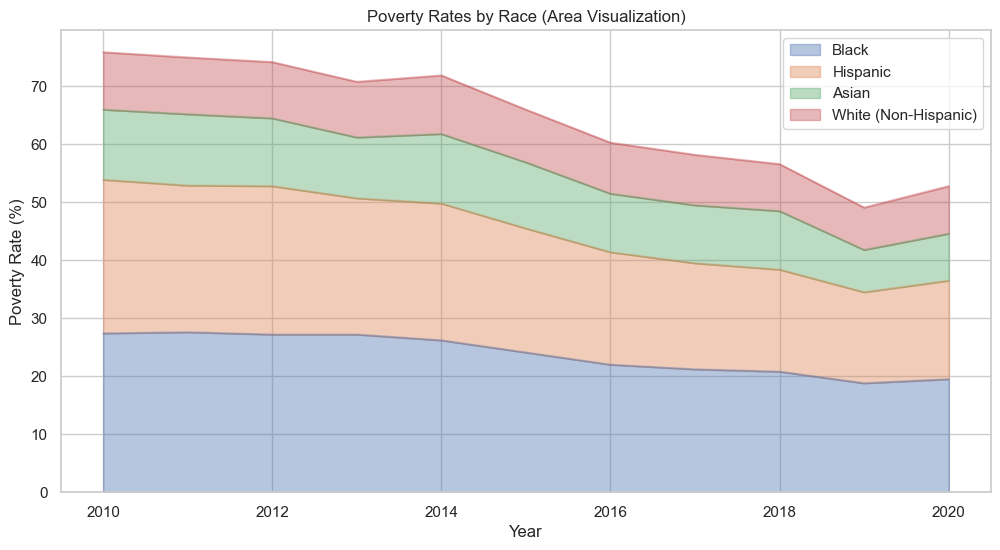

In [5]:
# Area Chart of Poverty Rates by Race

df.set_index("Year")[["Black","Hispanic","Asian","White (Non-Hispanic)"]].plot(kind="area", figsize=(12,6), alpha=0.4) 
plt.title("Poverty Rates by Race (Area Visualization)") 
plt.ylabel("Poverty Rate (%)") 
plt.show()

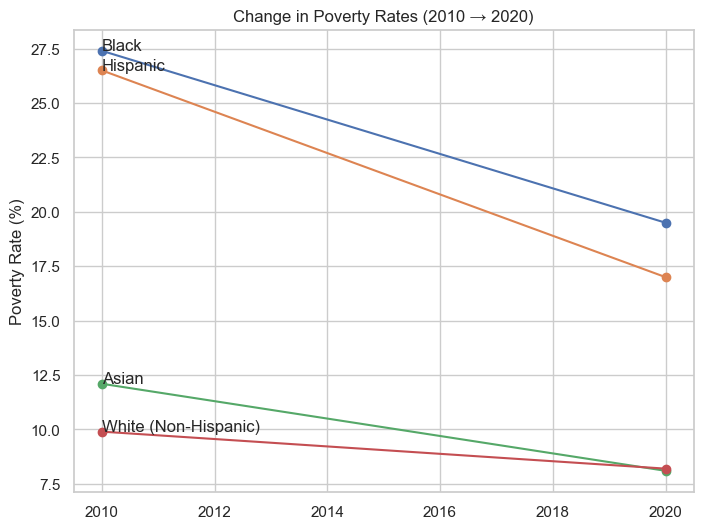

In [ ]:
# Slope Chart: Change in Poverty Rates from 2010 to 2020

start = df[df["Year"] == 2010]
end = df[df["Year"] == 2020]

race_cols = ["Black","Hispanic","Asian","White (Non-Hispanic)"]

plt.figure(figsize=(8,6))
for race in race_cols:
    plt.plot([2010, 2020], [start[race].values[0], end[race].values[0]], marker="o")
    plt.text(2010, start[race].values[0], race)
plt.title("Change in Poverty Rates (2010 to 2020)")
plt.ylabel("Poverty Rate (%)")
plt.show()

In [ ]:
# Reshape Poverty Data to Join with Maternal Mortality Data

poverty = pd.read_csv(r'\data\poverty-rates.csv')

poverty_long = poverty.melt(
    id_vars="Year",
    value_vars=["Black","Hispanic","Asian","White (Non-Hispanic)"],
    value_name="Poverty_Rate"
)

poverty_long.rename(columns={"variable": "race"}, inplace=True)

poverty_long.head()

,Year,race,Poverty_Rate
0,2010,Black,27.4
1,2011,Black,27.6
2,2012,Black,27.2
3,2013,Black,27.2
4,2014,Black,26.2


In [ ]:
# Standardize Column Names for Merging

mm = pd.read_csv(r'\data\cleaned_maternal_mortality.csv')

mm['race'] = mm['race'].replace({
    "Black or African American": "Black",
    "Hispanic": "Hispanic",
    "Asian or Pacific Islander": "Asian",
    "White": "White (Non-Hispanic)"
})

mm.rename(columns={"year": "Year"}, inplace=True)

mm.head()

,race,race_code,state,state_code,Year,year_code,icd10_113_cause_list,icd10_113_cause_list_code,deaths,population,crude_rate
0,Asian,A-PI,California,6.0,2004,2004.0,"#Pregnancy, childbirth and the puerperium (O00...",GR113-105,15.0,4750147.0,NaN
1,Asian,A-PI,California,6.0,2004,2004.0,"Other complications of pregnancy, childbirth a...",GR113-107,15.0,4750147.0,NaN
2,Asian,A-PI,California,6.0,2005,2005.0,"#Pregnancy, childbirth and the puerperium (O00...",GR113-105,11.0,4884264.0,NaN
3,Asian,A-PI,California,6.0,2005,2005.0,"Other complications of pregnancy, childbirth a...",GR113-107,11.0,4884264.0,NaN
4,Asian,A-PI,California,6.0,2006,2006.0,"#Pregnancy, childbirth and the puerperium (O00...",GR113-105,11.0,5013374.0,NaN


In [20]:
# Joining the Datasets

merged = pd.merge(poverty_long, 
                  mm,
                  left_on = ["Year", "race"],
                  right_on = ["Year", "race"],
                  how='inner'
                  )

merged.head()

,Year,race,Poverty_Rate,race_code,state,state_code,year_code,icd10_113_cause_list,icd10_113_cause_list_code,deaths,population,crude_rate
0,2010,Black,27.4,2054-5,California,6.0,2010.0,"#Pregnancy, childbirth and the puerperium (O00...",GR113-105,15.0,2718779.0,NaN
1,2010,Black,27.4,2054-5,California,6.0,2010.0,"Other complications of pregnancy, childbirth a...",GR113-107,15.0,2718779.0,NaN
2,2010,Black,27.4,2054-5,Florida,12.0,2010.0,"#Pregnancy, childbirth and the puerperium (O00...",GR113-105,20.0,3172720.0,0.6
3,2010,Black,27.4,2054-5,Florida,12.0,2010.0,"Other complications of pregnancy, childbirth a...",GR113-107,16.0,3172720.0,NaN
4,2010,Black,27.4,2054-5,Georgia,13.0,2010.0,"#Pregnancy, childbirth and the puerperium (O00...",GR113-105,23.0,3057817.0,0.8


In [21]:
# Aggregate Maternal Mortality Rate Data

mm_total = mm[mm['icd10_113_cause_list'].str.contains("O00", na=False)] # This filters for maternal causes of death based on ICD-10 codes starting with "O00"

mm_national = (
    mm_total
    .groupby(['Year', 'race'], as_index=False)
    .agg({
        'deaths': 'sum',
        'population': 'sum'
    }) 
) # This converts state-level data to national-level by summing deaths and population across all states for each year

mm_national['crude_rate'] = (mm_national['deaths'] / mm_national['population']) * 100000 # This calculates the maternal mortality rate per 100,000 live births


In [22]:
# Re-merge with Poverty Data

merged = poverty_long.merge(
    mm_national,
    on=['Year', 'race'],
    how='inner'
)

merged.head()

,Year,race,Poverty_Rate,deaths,population,crude_rate
0,2010,Black,27.4,173.0,21734953.0,0.795953
1,2011,Black,27.6,212.0,23165615.0,0.915149
2,2012,Black,27.2,263.0,27695601.0,0.949609
3,2013,Black,27.2,260.0,25190519.0,1.032134
4,2014,Black,26.2,300.0,29283211.0,1.024478


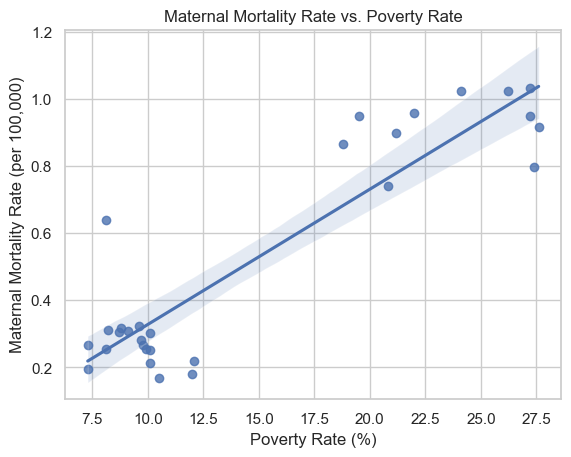

In [24]:
# Scatter Plot: Maternal Mortality Rate vs. Poverty Rate

sb.regplot(data=merged, x='Poverty_Rate', y='crude_rate')
plt.title("Maternal Mortality Rate vs. Poverty Rate")
plt.xlabel("Poverty Rate (%)")
plt.ylabel("Maternal Mortality Rate (per 100,000)")
plt.show()

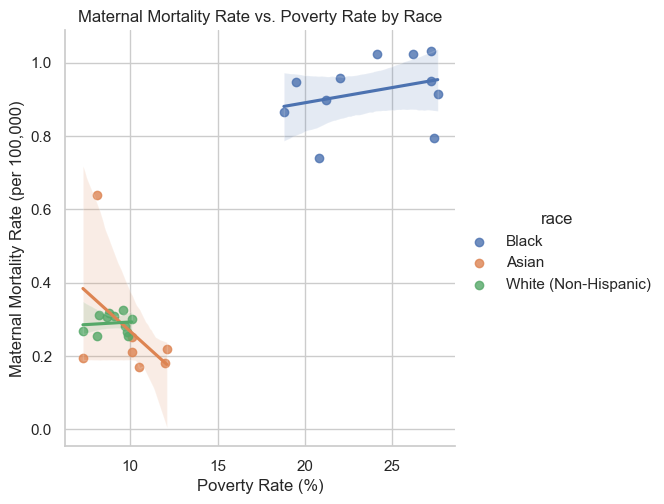

In [26]:
# Race-Specific Regression Plot

sb.lmplot(data=merged, x='Poverty_Rate', y='crude_rate', hue='race')
plt.title("Maternal Mortality Rate vs. Poverty Rate by Race")
plt.xlabel("Poverty Rate (%)")
plt.ylabel("Maternal Mortality Rate (per 100,000)")
plt.show()

In [27]:
# Correlation Coefficient Check

merged[['Poverty_Rate','crude_rate']].corr()

,Poverty_Rate,crude_rate
Poverty_Rate,1.000000,0.909803
crude_rate,0.909803,1.000000
